# Operationalizing Mismatch Diagnosis in Urban Flood Governance

## Thesis-aligned executable companion

This notebook follows the final thesis logic:

1. define the impact–visibility research problem;
2. document material and source accounting;
3. construct physical impact \(I_i\) on common grid units (5 km in the thesis, with a separate 1 km refinement);
4. reconstruct response/demand visibility \(R_i\);
5. compute the distributional SMI and \(\Delta_i\);
6. compute the directional standardised residual \(SR_i\) and mismatch magnitude;
7. interpret access constraints and planning implications;
8. state limitations and future extensions.

**Interpretation boundary:** \(R_i\) is digitally mediated visibility, not operational deployment.

## 1. Research question and analytical framework

The notebook operationalises the thesis question: where do physically reconstructed flood impacts and response/demand visibility diverge across space?

The physical and textual streams remain separate until they are aggregated to the same spatial unit. This prevents response signals from contaminating the impact surface and allows mismatch to be computed explicitly.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from flood_mismatch.data import load_grid
from flood_mismatch.impact import compute_impact_intensity, weight_sensitivity
from flood_mismatch.visibility import add_visibility_metrics, validate_llm_annotations
from flood_mismatch.mismatch import compute_mismatch
from flood_mismatch.planning import add_planning_actions

DATA = ROOT / "data"
OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

## 2. Material and source accounting

The thesis reports 481 records with usable location assignments, 450 unique X post IDs, 106 event-window records and 100 unique analytical posts after deduplication. These counts document the original research pipeline; the raw archive is not embedded in the thesis PDF.

In [2]:
source_accounting = pd.read_csv(DATA / "thesis_source_accounting.csv")
source_accounting

,stage,records,definition
0,Full scraped archive,NaN,Raw keyword-based pool before location assignment
1,Usable location assignments,481.0,Records with metadata coordinates or place-nam...
2,Unique X post IDs among located records,450.0,Some IDs occur more than once
3,Records in May 2023 event window,106.0,Event-window records before deduplication
4,Unique analytical X post IDs,100.0,Deduplicated observations used for spatial agg...


In [3]:
visibility_counts = pd.read_csv(DATA / "thesis_visibility_counts.csv")
visibility_counts

,municipality,event_window_records
0,Ravenna,81
1,Faenza,23
2,Conselice,1
3,Sant'Agata sul Santerno,1


## 3. Common-grid analytical units and scale boundary

The submitted thesis maps use 5 km grid cells; a post-thesis QGIS run provides a separate 1 km sensitivity comparison. The executable sample below represents synthetic common-grid units in tabular form and is not the empirical attribute table for either resolution. Its schema matches the diagnostic logic:

- inundation ratio;
- inundated-building ratio;
- road-disruption ratio;
- population;
- response/demand signal count.

In [4]:
grid = load_grid(DATA / "sample_grid_units.csv")
grid.head()

,grid_id,municipality,latitude,longitude,population,inundation_ratio,inundated_building_ratio,road_disruption_ratio,response_signal_count,direct_need_count,response_related_count,information_count
0,G001,Conselice,44.516,11.826,310,0.92,0.48,0.82,1,0,1,0
1,G002,Conselice,44.507,11.838,270,0.84,0.39,0.76,0,0,0,0
2,G003,Lugo,44.423,11.907,820,0.71,0.55,0.68,3,1,1,1
3,G004,Lugo,44.414,11.918,690,0.63,0.42,0.61,2,1,0,1
4,G005,Faenza,44.288,11.880,1450,0.58,0.72,0.49,13,4,4,5


In [5]:
assert grid["grid_id"].is_unique
assert grid[["inundation_ratio","inundated_building_ratio","road_disruption_ratio"]].apply(
    lambda s: s.between(0, 1).all()
).all()
grid.select_dtypes(include="number").describe().round(3)

,latitude,longitude,population,inundation_ratio,inundated_building_ratio,road_disruption_ratio,response_signal_count,direct_need_count,response_related_count,information_count
count,12.000,12.000,12.000,12.000,12.000,12.000,12.000,12.000,12.000,12.000
mean,44.380,11.930,1079.167,0.548,0.461,0.511,7.917,2.083,1.917,3.917
std,0.120,0.241,596.436,0.247,0.172,0.230,6.721,1.730,1.379,4.033
min,44.139,11.343,220.000,0.080,0.110,0.070,0.000,0.000,0.000,0.000
25%,44.286,11.855,595.000,0.410,0.362,0.402,1.750,0.750,1.000,0.750
50%,44.417,11.900,1275.000,0.545,0.450,0.520,7.500,2.000,2.000,3.000
75%,44.454,12.081,1487.500,0.730,0.580,0.692,13.250,3.250,3.000,6.000
max,44.516,12.243,1900.000,0.920,0.720,0.820,20.000,5.000,4.000,11.000


## 4. Physical impact reconstruction

The thesis defines physical impact as a weighted combination of three complementary ratios:

\[
I_i = w_1\,inundation\_ratio_i + w_2\,inundated\_building\_ratio_i + w_3\,road\_disruption\_ratio_i
\]

The baseline demo uses equal weights. This is an explicit modelling choice, not an empirically calibrated truth.

In [6]:
impact = compute_impact_intensity(grid, weights=(1/3, 1/3, 1/3))
impact[[
    "grid_id","municipality","inundation_ratio",
    "inundated_building_ratio","road_disruption_ratio",
    "impact_intensity_raw","impact_intensity_log"
]].head()

,grid_id,municipality,inundation_ratio,inundated_building_ratio,road_disruption_ratio,impact_intensity_raw,impact_intensity_log
0,G001,Conselice,0.92,0.48,0.82,0.740000,0.553885
1,G002,Conselice,0.84,0.39,0.76,0.663333,0.508824
2,G003,Lugo,0.71,0.55,0.68,0.646667,0.498753
3,G004,Lugo,0.63,0.42,0.61,0.553333,0.440403
4,G005,Faenza,0.58,0.72,0.49,0.596667,0.467918


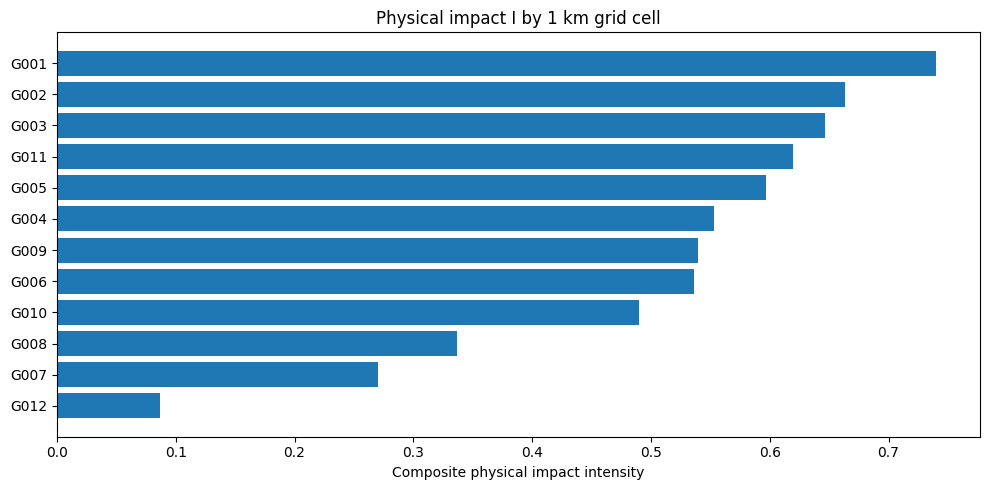

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered = impact.sort_values("impact_intensity_raw")
ax.barh(ordered["grid_id"], ordered["impact_intensity_raw"])
ax.set_xlabel("Composite physical impact intensity")
ax.set_title("Physical impact I by synthetic spatial unit")
fig.tight_layout()
plt.show()

### Weighting transparency

The submitted thesis states that formal calibration and sensitivity testing were not available. The following demo compares several bounded alternatives to show how a future robustness check can be implemented.

In [8]:
schemes = {
    "equal": (1/3, 1/3, 1/3),
    "inundation_emphasis": (0.50, 0.25, 0.25),
    "building_emphasis": (0.25, 0.50, 0.25),
    "access_emphasis": (0.25, 0.25, 0.50),
}
sensitivity = weight_sensitivity(grid, schemes)
sensitivity.pivot(index="grid_id", columns="scheme", values="impact_intensity_raw").round(3)

scheme,access_emphasis,building_emphasis,equal,inundation_emphasis
grid_id,,,,
G001,0.760,0.675,0.740,0.785
G002,0.688,0.595,0.663,0.708
G003,0.655,0.622,0.647,0.662
G004,0.568,0.520,0.553,0.572
G005,0.570,0.628,0.597,0.592
G006,0.512,0.568,0.537,0.530
G007,0.258,0.280,0.270,0.272
G008,0.325,0.345,0.337,0.340
G009,0.542,0.558,0.540,0.520


## 5. LLM-enabled response and demand visibility

The thesis does not treat social-media density as a direct measure of deployed resources. It reconstructs a socio-technical visibility field from geocoded and semantically filtered signals.

In [9]:
annotations = validate_llm_annotations(
    pd.read_csv(DATA / "sample_llm_annotations.csv")
)
annotations[[
    "post_id","category","response_type","place_mention",
    "confidence","rationale"
]]

,post_id,category,response_type,place_mention,confidence,rationale
0,P001,Health risk,demand,Conselice,0.95,Stagnant water and contamination concern
1,P002,Infrastructure disruption,demand,Lugo,0.88,Road access remains disrupted
2,P003,Evacuation and entrapment,response,Faenza,0.92,Boat rescue activity reported
3,P004,Resource request,demand,Conselice,0.94,Request for pumps and clean water
4,P005,Information,information,Ravenna,0.89,Regional warning and road information
5,P006,Infrastructure disruption,demand,Sant'Agata sul Santerno,0.91,Access constraints reported
6,P007,Resource request,response,Cesena,0.90,Food distribution reported
7,P008,Information,information,Bologna,0.87,Regional coordination message


In [10]:
visibility = add_visibility_metrics(impact)
visibility[[
    "grid_id","municipality","response_visibility_raw",
    "response_visibility_log","visibility_per_10000"
]].head()

,grid_id,municipality,response_visibility_raw,response_visibility_log,visibility_per_10000
0,G001,Conselice,1,0.693147,32.258065
1,G002,Conselice,0,0.000000,0.000000
2,G003,Lugo,3,1.386294,36.585366
3,G004,Lugo,2,1.098612,28.985507
4,G005,Faenza,13,2.639057,89.655172


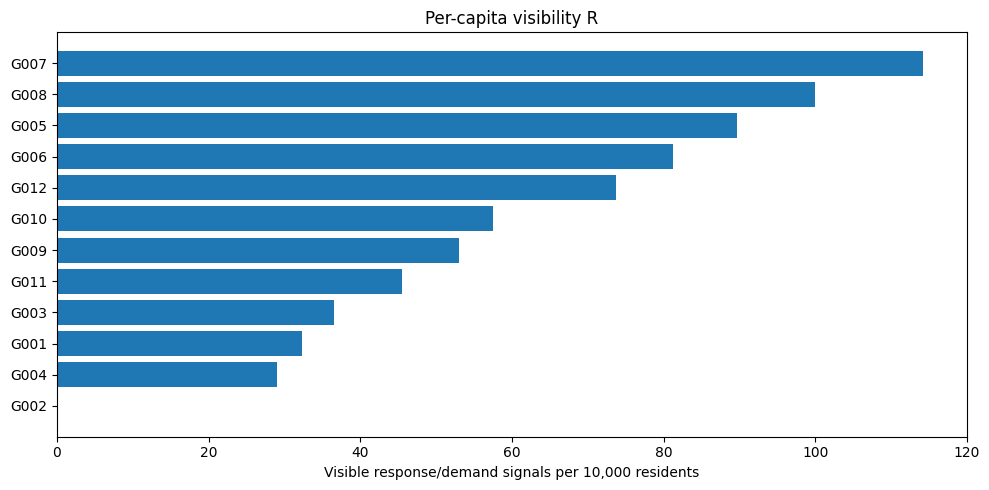

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered = visibility.sort_values("visibility_per_10000")
ax.barh(ordered["grid_id"], ordered["visibility_per_10000"])
ax.set_xlabel("Visible response/demand signals per 10,000 residents")
ax.set_title("Per-capita visibility R")
fig.tight_layout()
plt.show()

## 6. Share-based Spatial Mismatch Index

The distributional residual is:

\[
\Delta_i = \widetilde{R}_i - \widetilde{I}_i
\]

and:

\[
SMI = \frac{1}{2}\sum_i |\Delta_i|
\]

A negative \(\Delta_i\) indicates under-visibility relative to the cell's share of impact.

In [12]:
mismatch, summary = compute_mismatch(visibility)
print(f"Share-based SMI = {summary.smi:.3f}")
mismatch[[
    "grid_id","municipality","impact_share","visibility_share",
    "delta_share","smi_contribution"
]].sort_values("smi_contribution", ascending=False)

Share-based SMI = 0.472


,grid_id,municipality,impact_share,visibility_share,delta_share,smi_contribution
6,G007,Ravenna,0.044408,0.210526,0.166118,0.083059
11,G012,Bologna,0.014254,0.147368,0.133114,0.066557
7,G008,Ravenna,0.055373,0.168421,0.113048,0.056524
0,G001,Conselice,0.121711,0.010526,-0.111184,0.055592
1,G002,Conselice,0.109101,0.000000,-0.109101,0.054550
10,G011,Sant'Agata sul Santerno,0.101974,0.010526,-0.091447,0.045724
2,G003,Lugo,0.106360,0.031579,-0.074781,0.037390
3,G004,Lugo,0.091009,0.021053,-0.069956,0.034978
4,G005,Faenza,0.098136,0.136842,0.038706,0.019353
5,G006,Faenza,0.088268,0.105263,0.016996,0.008498


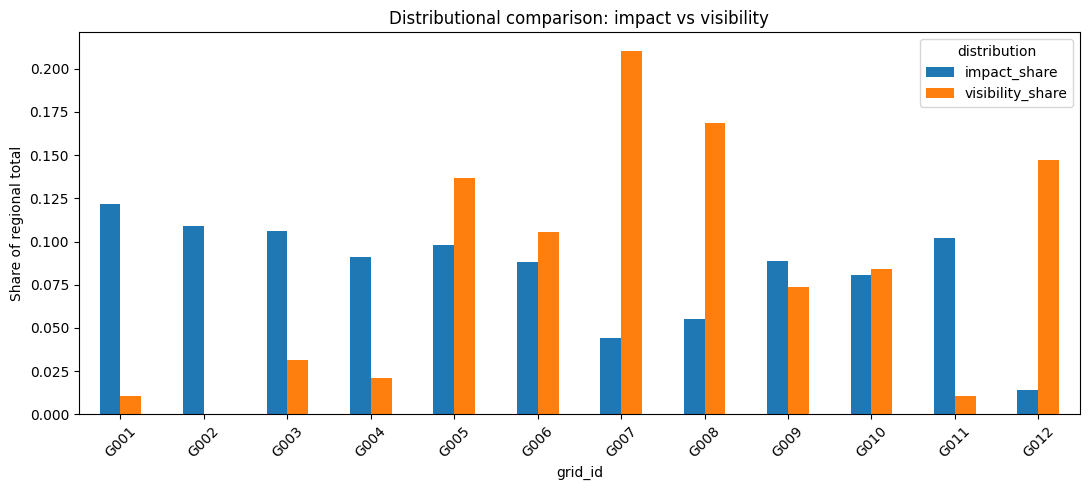

In [13]:
long = mismatch.melt(
    id_vars="grid_id",
    value_vars=["impact_share","visibility_share"],
    var_name="distribution",
    value_name="share",
)
pivot = long.pivot(index="grid_id", columns="distribution", values="share")
ax = pivot.plot(kind="bar", figsize=(11,5))
ax.set_ylabel("Share of regional total")
ax.set_title("Distributional comparison: impact vs visibility")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Directional SR surface and mismatch magnitude

The thesis uses a separate directional diagnostic:

\[
SR_i = z(\log(1+I_i)) - z(\log(1+R_i))
\]

- \(SR_i>0\): under-visibility relative to impact;
- \(SR_i<0\): over-visibility relative to impact;
- normalised \(|SR_i|\): mismatch magnitude.

This surface is complementary to the share-based SMI and must not be confused with it.

In [14]:
mismatch[[
    "grid_id","municipality","standardised_residual",
    "mismatch_magnitude","diagnostic_direction"
]].sort_values("standardised_residual", ascending=False)

,grid_id,municipality,standardised_residual,mismatch_magnitude,diagnostic_direction
1,G002,Conselice,2.717280,0.797003,under_visibility
0,G001,Conselice,2.346550,0.688265,under_visibility
10,G011,Sant'Agata sul Santerno,1.791007,0.525319,under_visibility
2,G003,Lugo,1.196887,0.351058,under_visibility
3,G004,Lugo,1.042520,0.305781,under_visibility
8,G009,Forli,-0.044814,0.013144,approximate_balance
4,G005,Faenza,-0.346028,0.101493,over_visibility
5,G006,Faenza,-0.392933,0.115251,over_visibility
9,G010,Cesena,-0.423939,0.124345,over_visibility
7,G008,Ravenna,-1.929797,0.566027,over_visibility


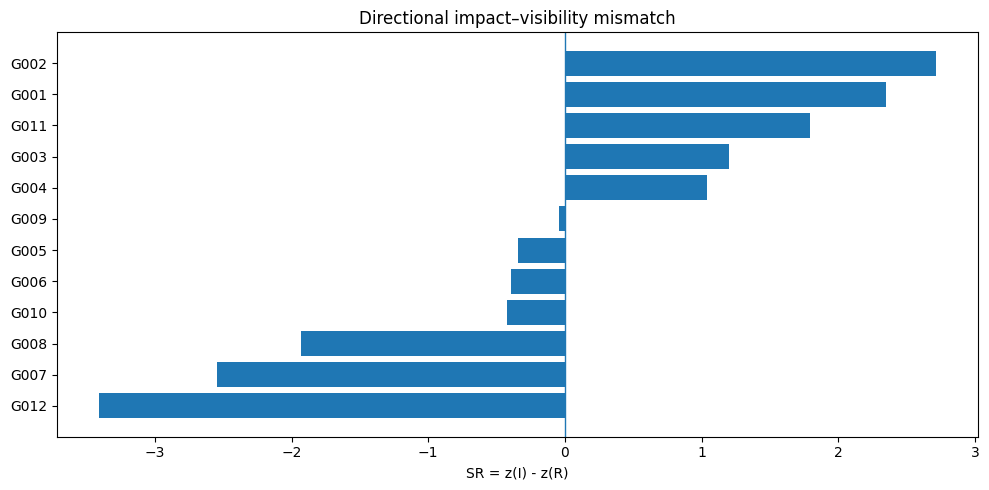

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered = mismatch.sort_values("standardised_residual")
ax.barh(ordered["grid_id"], ordered["standardised_residual"])
ax.axvline(0, linewidth=1)
ax.set_xlabel("SR = z(I) - z(R)")
ax.set_title("Directional impact–visibility mismatch")
fig.tight_layout()
plt.show()

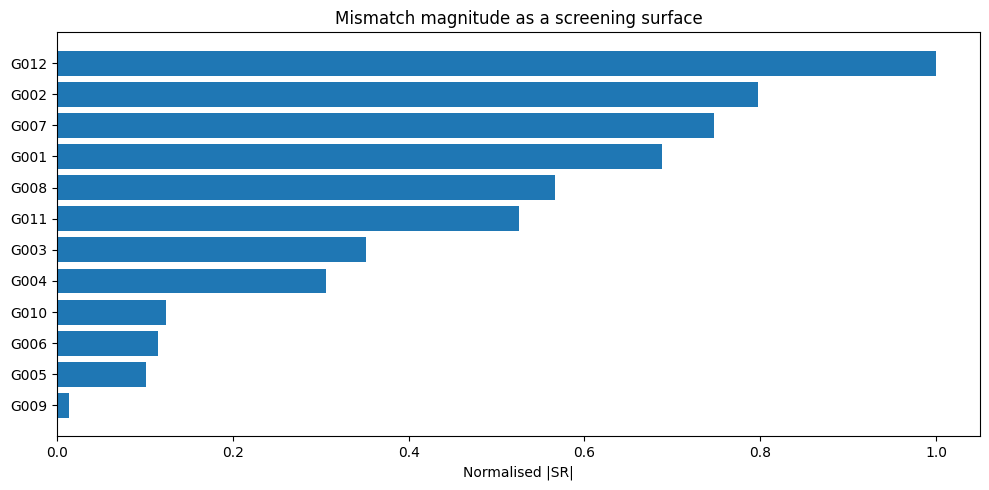

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered = mismatch.sort_values("mismatch_magnitude")
ax.barh(ordered["grid_id"], ordered["mismatch_magnitude"])
ax.set_xlabel("Normalised |SR|")
ax.set_title("Mismatch magnitude as a screening surface")
fig.tight_layout()
plt.show()

## 8. Accessibility context and planning interpretation

Road disruption is part of \(I_i\) because accessibility loss affects both physical reach and the probability that peripheral impacts become visible. The proposal logic distinguishes under-visibility from over-visibility rather than applying one generic response.

In [17]:
diagnosis = add_planning_actions(mismatch)
diagnosis.sort_values(
    "standardised_residual", ascending=False
)[[
    "grid_id", "municipality", "road_disruption_ratio",
    "diagnostic_direction", "planning_action"
]]

,grid_id,municipality,road_disruption_ratio,diagnostic_direction,planning_action
1,G002,Conselice,0.76,under_visibility,"Protect critical access links, prepare detours..."
0,G001,Conselice,0.82,under_visibility,"Protect critical access links, prepare detours..."
10,G011,Sant'Agata sul Santerno,0.73,under_visibility,"Protect critical access links, prepare detours..."
2,G003,Lugo,0.68,under_visibility,"Protect critical access links, prepare detours..."
3,G004,Lugo,0.61,under_visibility,"Protect critical access links, prepare detours..."
8,G009,Forli,0.55,approximate_balance,Maintain monitoring; no strong directional mis...
4,G005,Faenza,0.49,over_visibility,Apply attention-calibration rules and cross-ch...
5,G006,Faenza,0.44,over_visibility,Apply attention-calibration rules and cross-ch...
9,G010,Cesena,0.47,over_visibility,Apply attention-calibration rules and cross-ch...
7,G008,Ravenna,0.29,over_visibility,Apply attention-calibration rules and cross-ch...


## 9. Results boundary, critical reflection and outlook

The executable sample demonstrates the complete calculation chain, but it does not independently reproduce the empirical maps in the thesis.

Key limitations retained from the thesis:

- impact depends on the temporal and spatial quality of the flood footprint and exposure layers;
- grid aggregation smooths local heterogeneity;
- visibility is participation-driven and urban-biased;
- low visibility does not prove absent operational response;
- static SMI does not encode event timing;
- weighting sensitivity and multi-source triangulation require further development.

Future extensions should add phase-specific mismatch, bias-aware evidence thresholds, channel-by-channel triangulation, planning-unit translation and controlled cross-case replication.

In [18]:
diagnosis.to_csv(
    OUTPUTS / "thesis_aligned_mismatch_result.csv",
    index=False
)
print("Saved:", OUTPUTS / "thesis_aligned_mismatch_result.csv")

Saved: /mnt/data/geoai-flood-mismatch-thesis-aligned/outputs/thesis_aligned_mismatch_result.csv
